# Trend analysis for each age class (vs Year)

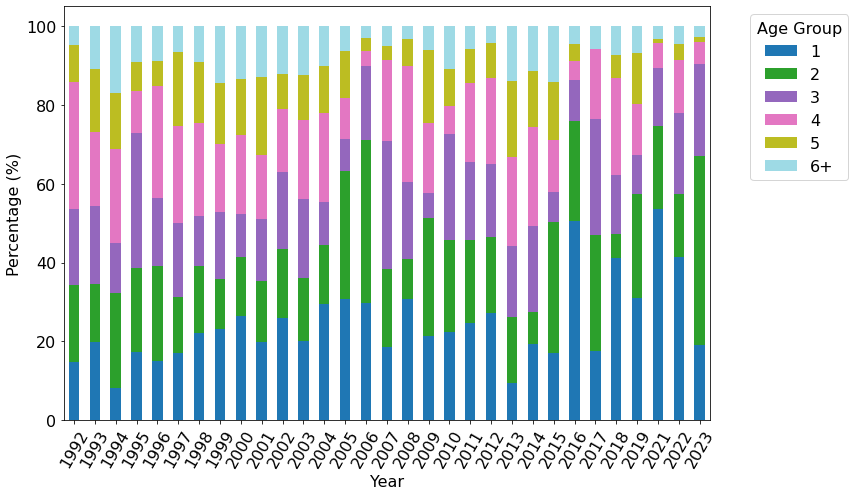

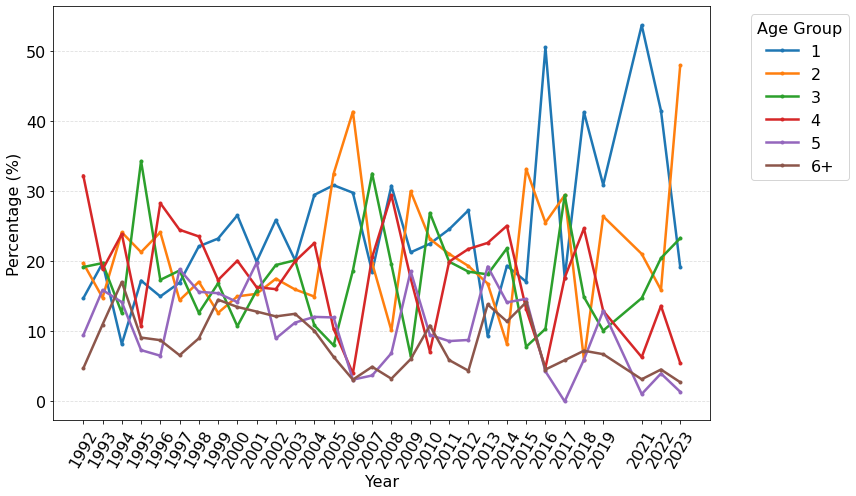

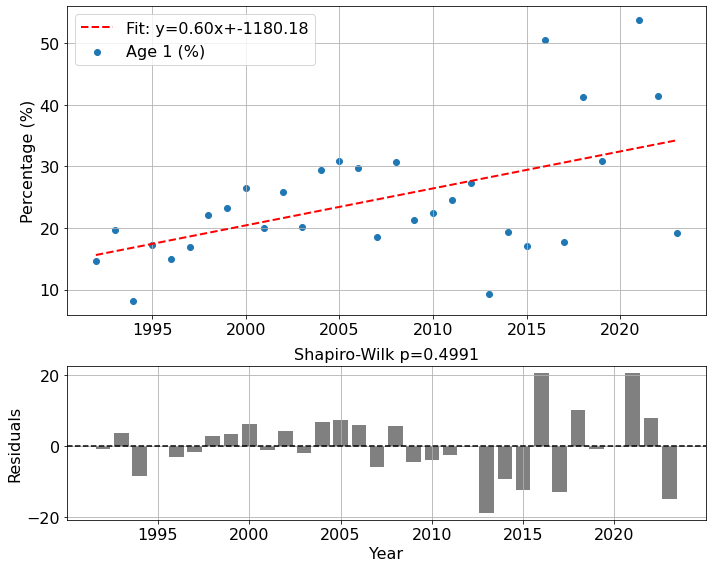

=== Female Age Group: 1 ===
  Slope: 0.60, Intercept: -1180.18
  R²: 0.28, p-value: 0.0024
  Shapiro-Wilk: stat = 0.9693, p = 0.4991



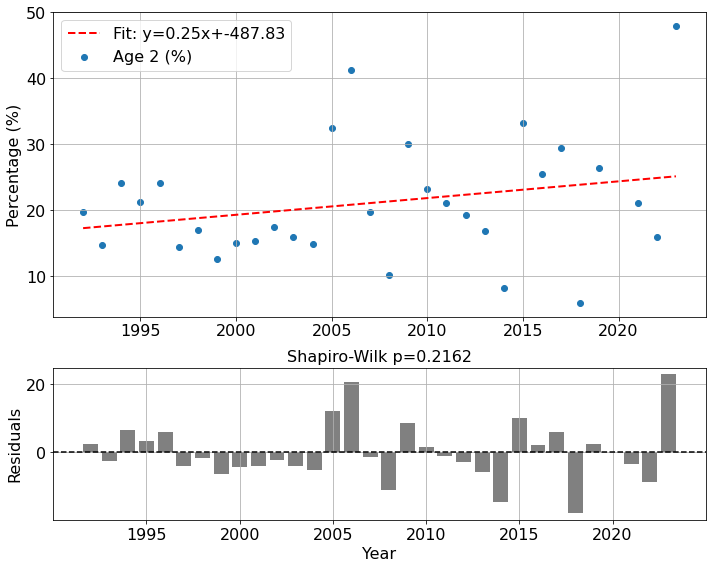

=== Female Age Group: 2 ===
  Slope: 0.25, Intercept: -487.83
  R²: 0.07, p-value: 0.1639
  Shapiro-Wilk: stat = 0.9552, p = 0.2162



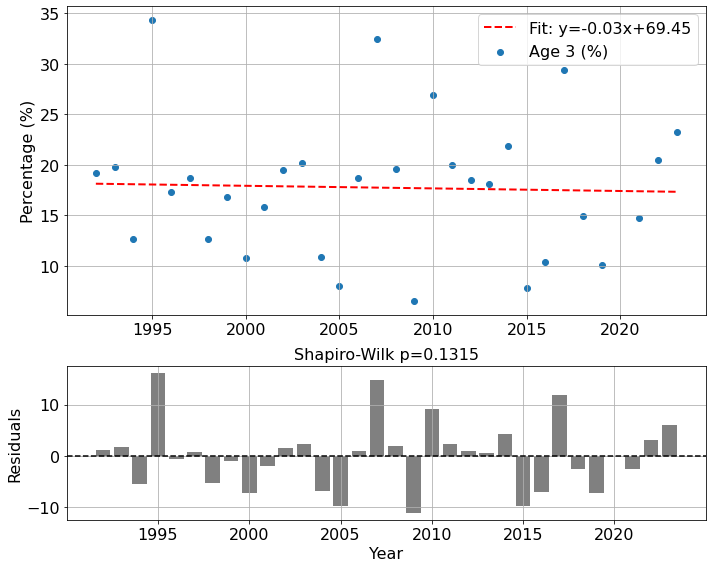

=== Female Age Group: 3 ===
  Slope: -0.03, Intercept: 69.45
  R²: 0.00, p-value: 0.8520
  Shapiro-Wilk: stat = 0.9473, p = 0.1315



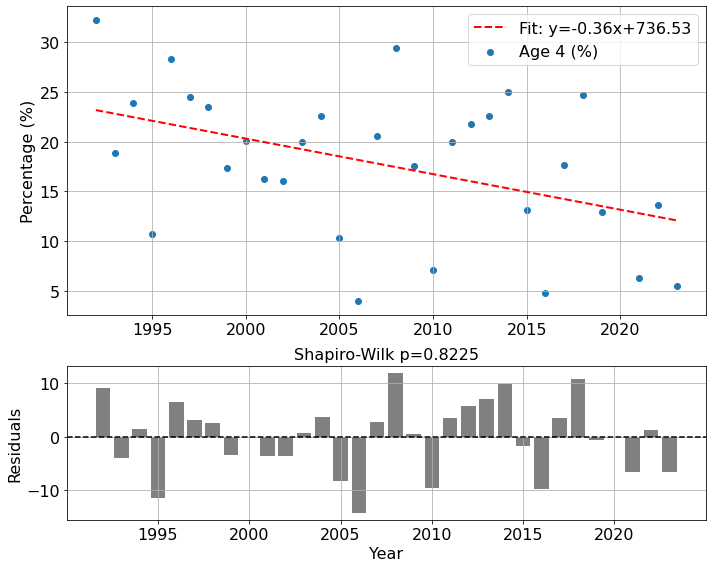

=== Female Age Group: 4 ===
  Slope: -0.36, Intercept: 736.53
  R²: 0.20, p-value: 0.0128
  Shapiro-Wilk: stat = 0.9804, p = 0.8225



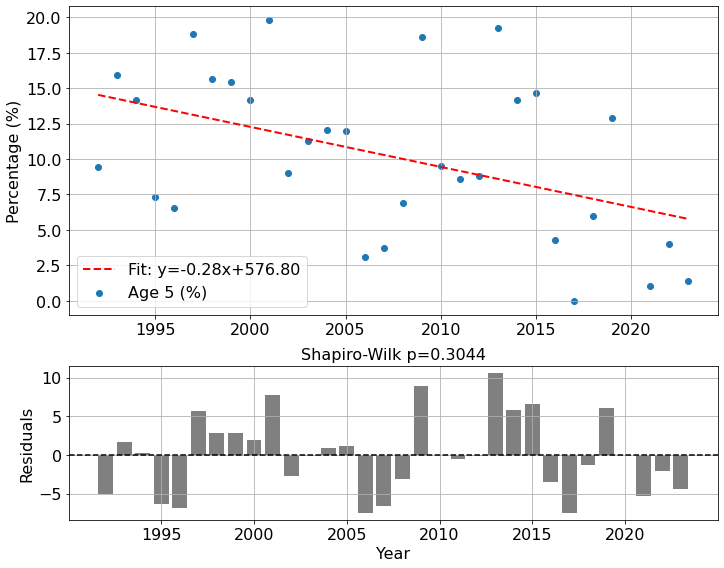

=== Female Age Group: 5 ===
  Slope: -0.28, Intercept: 576.80
  R²: 0.21, p-value: 0.0098
  Shapiro-Wilk: stat = 0.9607, p = 0.3044



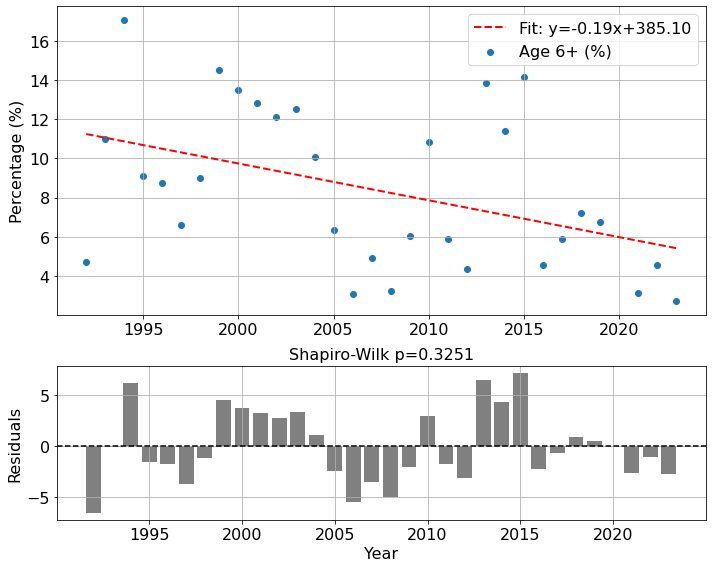

=== Female Age Group: 6+ ===
  Slope: -0.19, Intercept: 385.10
  R²: 0.18, p-value: 0.0160
  Shapiro-Wilk: stat = 0.9618, p = 0.3251

Excel workbook saved as 'female_age_summary.xlsx'


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, shapiro

# Read data from Excel
input_file = "data.xlsx"
df = pd.read_excel(input_file, sheet_name="AllFemales", index_col=0)


# Rename columns to match the age_order format
df.columns = ['1','2','3','4','5','6+']
age_order = ['1','2','3','4','5','6+']

# Ensure index is integer year
df.index = df.index.astype(int)

summary_table = df.copy()  # Keep original counts

# Counts and percentages
age_percentages = (summary_table.T / summary_table.sum(axis=1)).T * 100
age_percentages = age_percentages.round(2)

combined = pd.concat([summary_table, age_percentages], axis=1, keys=['Count','Percentage'])
combined = combined.swaplevel(axis=1).sort_index(axis=1, level=0)

# Visualization of annual age structure as a stacked bar plot
bar_plot = age_percentages.plot(kind='bar', stacked=True, figsize=(12,7), colormap='tab20')
#plt.title('Females Age Distribution (Age 1–5 and 6+) in April–June by Year')
plt.xlabel('Year', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=16)
plt.xticks(rotation=60, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(title='Age Group',title_fontsize=16,fontsize=16, bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
bar_plot.figure.savefig('age_distribution_by_year.png', dpi=300)
bar_plot.figure.savefig("age_distribution_by_year.pdf",bbox_inches="tight")
plt.show()

# Visualization of annual age structure as a line plot
# While the stacked bar plot emphasizes the annual composition of the female population, 
# the line plot shows temporal changes within individual age groups.

ax = age_percentages.plot(kind='line',figsize=(12, 7), marker='o', markersize=3, linewidth=2.5)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=16)
plt.xticks(
    ticks=age_percentages.index,
    labels=age_percentages.index,
    rotation=60,
    fontsize=16
)
plt.yticks(fontsize=16)
plt.legend(
    title='Age Group',
    title_fontsize=16,
    fontsize=16,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
# Save in both vector and raster formats
ax.figure.savefig(
    'age_distribution_by_year_lineplot.pdf',
    bbox_inches='tight'
)
ax.figure.savefig(
    'age_distribution_by_year_lineplot.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Trend analysis for each age group 
for age_group in age_order:
    x = age_percentages.index
    y = age_percentages[age_group]

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    predicted = slope*x + intercept
    residuals = y - predicted
    r_squared = r_value**2
    shapiro_stat, shapiro_p = shapiro(residuals)
    
    fig, (ax_main, ax_resid) = plt.subplots(2,1, figsize=(10,8), gridspec_kw={'height_ratios':[2,1]})
    ax_main.scatter(x, y, label=f'Age {age_group} (%)', color='tab:blue')
    ax_main.plot(x, predicted, color='red', linestyle='--', linewidth=2, label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
    #ax_main.set_title(f'Regression for Age Group {age_group}')
    ax_main.set_ylabel('Percentage (%)', fontsize=16)
    ax_main.tick_params(axis='both', labelsize=16)
    ax_main.legend(fontsize=16)
    ax_main.grid(True)

    ax_resid.bar(x, residuals, color='gray')
    ax_resid.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax_resid.set_title(f'Shapiro-Wilk p={shapiro_p:.4f}', fontsize=16)
    ax_resid.set_xlabel('Year', fontsize=16)
    ax_resid.set_ylabel('Residuals', fontsize=16)
    ax_resid.tick_params(axis='both', labelsize=16)
    ax_resid.grid(True)
    plt.tight_layout()
    fig.savefig(f"age_{age_group}_scatter_residuals.png", dpi=300)
    fig.savefig(f"age_{age_group}_scatter_residuals.pdf",bbox_inches="tight")
    plt.show()

    print(f"=== Female Age Group: {age_group} ===")
    print(f"  Slope: {slope:.2f}, Intercept: {intercept:.2f}")
    print(f"  R²: {r_squared:.2f}, p-value: {p_value:.4f}")
    print(f"  Shapiro-Wilk: stat = {shapiro_stat:.4f}, p = {shapiro_p:.4f}\n")

# Excel export 
with pd.ExcelWriter("female_age_summary.xlsx", engine='openpyxl') as writer:
    summary_table.to_excel(writer, sheet_name='Counts')
    age_percentages.to_excel(writer, sheet_name='Percentages')
    combined.to_excel(writer, sheet_name='Combined')
print("Excel workbook saved as 'female_age_summary.xlsx'")



# Water temperature ($^{o}C$) trend vs Year

Linear regression result:
  Slope: 0.0708 °C/year
  Intercept: -133.69
  R-squared: 0.2305
  P-value: 6.2734e-03
  Std error of slope: 0.0240


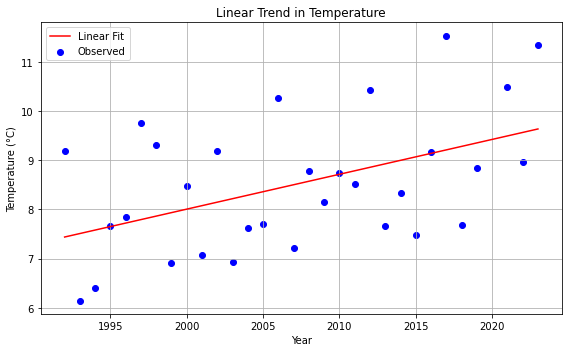

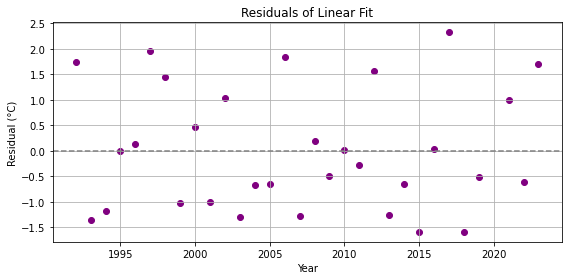

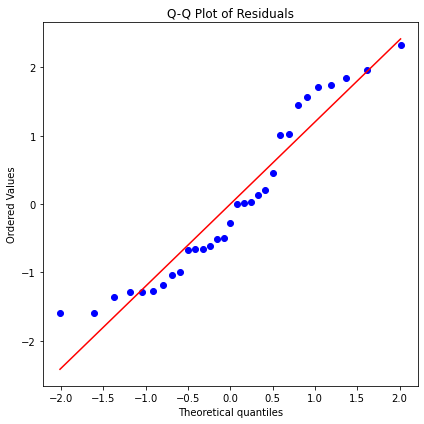

In [6]:
import pandas as pd
from scipy.stats import linregress, shapiro, probplot
import matplotlib.pyplot as plt
import scipy.stats as stats

# Read Excel file and sheet
df = pd.read_excel("data.xlsx", sheet_name="Temperature")

# Clean column names (optional but safe)
df.columns = df.columns.str.strip()  # remove extra spaces

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(df['Year'], df['Temperature'])

# Print regression results
print("Linear regression result:")
print(f"  Slope: {slope:.4f} °C/year")
print(f"  Intercept: {intercept:.2f}")
print(f"  R-squared: {r_value**2:.4f}")
print(f"  P-value: {p_value:.4e}")
print(f"  Std error of slope: {std_err:.4f}")

# Predicted values and residuals
df['Predicted'] = intercept + slope * df['Year']
df['Residual'] = df['Temperature'] - df['Predicted']

# Plot temperature with linear fit
plt.figure(figsize=(8,5))
plt.scatter(df['Year'], df['Temperature'], color='blue', label='Observed')
plt.plot(df['Year'], df['Predicted'], 'r-', label='Linear Fit')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Linear Trend in Temperature')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Temperature_Trend.png", dpi=300)
plt.show()

# Plot residuals
plt.figure(figsize=(8,4))
plt.axhline(0, color='gray', linestyle='--')
plt.scatter(df['Year'], df['Residual'], color='purple')
plt.xlabel('Year')
plt.ylabel('Residual (°C)')
plt.title('Residuals of Linear Fit')
plt.grid(True)
plt.tight_layout()
plt.savefig("Temperature_Residuals.png", dpi=300)
plt.show()

# Q-Q plot for residuals
plt.figure(figsize=(6,6))
stats.probplot(df['Residual'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.savefig("Temperature_QQplot.png", dpi=300)
plt.show()


# Female CPUE trend vs water temperature 


CPUE vs Temperature by Year:
    Year      CPUE  Temperature    Fitted  Residuals
0   1992  4.500000     9.187611  3.916171   0.583829
1   1993  4.558333     6.148306  5.744168  -1.185835
2   1994  3.766667     6.396370  5.594970  -1.828303
3   1995  5.125000     7.653846  4.838658   0.286342
4   1996  6.008333     7.849184  4.721171   1.287162
5   1997  5.308333     9.753756  3.575662   1.732671
6   1998  5.275000     9.311086  3.841907   1.433093
7   1999  5.341667     6.903125  5.290181   0.051486
8   2000  6.058333     8.467517  4.349273   1.709060
9   2001  5.266667     7.077896  5.185064   0.081602
10  2002  5.566667     9.178652  3.921560   1.645107
11  2003  6.000000     6.931113  5.273347   0.726653
12  2004  5.504202     7.614918  4.862071   0.642131
13  2005  4.591667     7.703581  4.808744  -0.217078
14  2006  2.812500    10.270979  3.264577  -0.452077
15  2007  6.075000     7.221247  5.098845   0.976155
16  2008  6.175000     8.773072  4.165496   2.009504
17  2009  4.9750

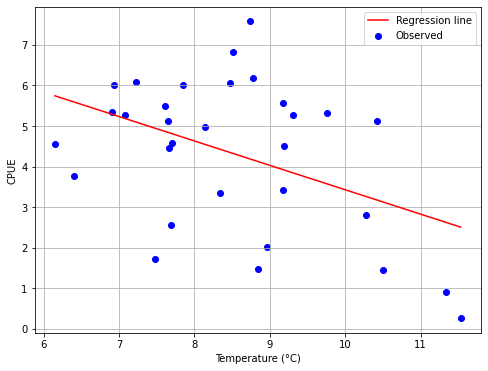

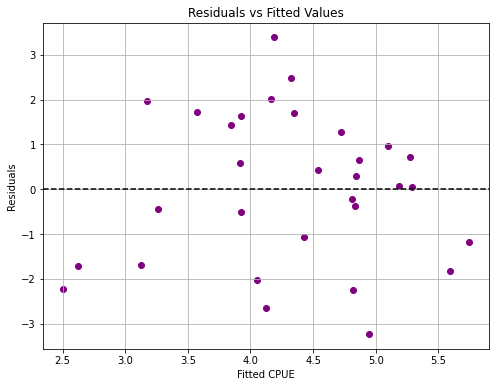

In [10]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy import stats

# === Read the Excel file ===
file_path = 'data.xlsx'

df_all = pd.read_excel(file_path, sheet_name='AllFemales')
df_tows = pd.read_excel(file_path, sheet_name='TowCount')
df_temp = pd.read_excel(file_path, sheet_name='Temperature')

# === Compute total catch for each year ===
age_columns = ['Age1', 'Age2', 'Age3', 'Age4', 'Age5', 'Age6+']
df_all['TotalCatch'] = df_all[age_columns].sum(axis=1)

# === Merge with TowCount and Temperature data ===
df_merged = pd.merge(df_all, df_tows, on='Year')
df_final = pd.merge(df_merged, df_temp, on='Year')

# === Compute CPUE ===
df_final['CPUE'] = df_final['TotalCatch'] / df_final['Tows']

# === Create independent DataFrame for analysis ===
df_result = df_final[['Year', 'CPUE', 'Temperature']].copy() 

# === Linear regression: CPUE ~ Temperature ===
X = sm.add_constant(df_result['Temperature'])
y = df_result['CPUE']

model = sm.OLS(y, X).fit()
df_result['Fitted'] = model.fittedvalues
df_result['Residuals'] = model.resid

print("\nCPUE vs Temperature by Year:")
print(df_result)

print("\nRegression summary:")
print(model.summary())

# === Shapiro–Wilk test for residuals normality ===
shapiro_stat, shapiro_p = stats.shapiro(df_result['Residuals'])
print("\nShapiro–Wilk test for residuals:")
print(f"Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

# === Scatterplot with regression line ===
plt.figure(figsize=(8,6))
plt.scatter(df_result['Temperature'], df_result['CPUE'], color='blue', label='Observed')
temp_vals = np.linspace(df_result['Temperature'].min(), df_result['Temperature'].max(), 100)
pred_vals = model.params['const'] + model.params['Temperature'] * temp_vals
plt.plot(temp_vals, pred_vals, color='red', label='Regression line')
plt.xlabel('Temperature (°C)')
plt.ylabel('CPUE')
plt.legend()
plt.grid(True)
plt.savefig("femaleCPUEvsT.png", dpi=300)
plt.show()

# === Residuals vs Fitted plot ===
plt.figure(figsize=(8,6))
plt.scatter(df_result['Fitted'], df_result['Residuals'], color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Fitted CPUE')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.grid(True)
plt.show()

